In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# ══════════════════════════════════════════════════════
# Q5 — FULLY CONNECTED NETWORK (TAM BAĞLANTILI AĞ)
# ══════════════════════════════════════════════════════
#
# Q3'te iki katmanlı ağ yaptık:
#   x → W1 → ReLU → W2 → skor
#
# Q5'te bunu genelleştiriyoruz:
#   x → W1 → ReLU → W2 → ReLU → W3 → ... → skor
#
# İstediğimiz kadar katman ekleyebiliriz!
# Buna "Fully Connected" veya "Dense" ağ denir
#
# Neden daha fazla katman?
#   2 katman → orta karmaşıklıkta şekiller öğrenir
#   3 katman → daha karmaşık
#   N katman → çok daha karmaşık örüntüler!
#
# Ama dikkat:
#   Çok katman → çok parametre → eğitmesi zor
#   Az veri + çok katman → overfitting (ezberler, genelleyemez)
# ══════════════════════════════════════════════════════

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
x  = np.array([[10, 20, 30]])  # 1 görüntü, 3 piksel
W1 = np.array([[0.1, 0.4, 0.7, 0.1],
               [0.2, 0.5, 0.8, 0.3],
               [0.3, 0.6, 0.9, 0.5]])  # (3, 4)
b1 = np.array([1, 2, 3, 4])

sonuc = x @ W1 + b1
print("x @ W1 + b1 =", sonuc)
print("\nHer sayı bir nöronun çıktısı!")
print("4 nöron → 4 farklı özellik öğrendi")

x @ W1 + b1 = [[15. 34. 53. 26.]]

Her sayı bir nöronun çıktısı!
4 nöron → 4 farklı özellik öğrendi


In [4]:
# ══════════════════════════════════════════════════════
# MODÜLER YAPI — HER KATMAN AYRI FONKSİYON
# ══════════════════════════════════════════════════════
#
# Q3'te böyle yazdık (hepsi iç içe):
#   h1 = ReLU(X @ W1 + b1)
#   h2 = ReLU(h1 @ W2 + b2)
#   skor = h2 @ W3 + b3
#
# Q5'te böyle yazacağız (modüler):
#   fc_forward()   → tam bağlantılı katman ileri geçiş
#   relu_forward() → ReLU ileri geçiş
#   fc_backward()  → tam bağlantılı katman geri geçiş
#   relu_backward()→ ReLU geri geçiş
#
# Neden modüler?
#   İstediğin kadar katman ekleyip çıkarabilirsin
#   Her katmanı ayrı test edebilirsin
#   Kod çok daha temiz ve anlaşılır
# ══════════════════════════════════════════════════════

def fc_forward(x, W, b):
    """
    Tam bağlantılı katman — ileri geçiş
    x: girdi, shape (N, D)
    W: ağırlık, shape (D, H)
    b: bias, shape (H,)
    döndürür: out=(N,H), cache=(x,W,b)
    """
    out = x @ W + b
    cache = (x, W, b)  # backward için sakla
    return out, cache

def relu_forward(x):
    """
    ReLU aktivasyonu — ileri geçiş
    Negatif değerleri sıfırla
    """
    out = np.maximum(0, x)
    cache = x  # backward için sakla
    return out, cache

def fc_backward(grad_out, cache):
    """
    Tam bağlantılı katman — geri geçiş
    grad_out: üstten gelen gradient
    cache: forward'dan gelen (x, W, b)
    """
    x, W, b = cache
    grad_x = grad_out @ W.T        # x'e gradient
    grad_W = x.T @ grad_out        # W'ya gradient
    grad_b = np.sum(grad_out, axis=0)  # b'ye gradient
    return grad_x, grad_W, grad_b

def relu_backward(grad_out, cache):
    """
    ReLU — geri geçiş
    Sadece forward'da pozitif olan yerlerden gradient geçer
    """
    x = cache
    grad_x = grad_out * (x > 0)
    return grad_x

print("Katman fonksiyonları hazır!")

Katman fonksiyonları hazır!


In [5]:
# ══════════════════════════════════════════════════════
# 3 KATMANLI AĞ — FORWARD PASS
# ══════════════════════════════════════════════════════
#
# Q3'te 2 katman vardı:
#   x → W1 → ReLU → W2 → skor
#
# Şimdi 3 katman:
#   x → W1 → ReLU → W2 → ReLU → W3 → skor
#
# Her katman bir öncekinin çıktısını alıyor
# ══════════════════════════════════════════════════════

np.random.seed(0)

# Veri
X = np.array([
    [1.0, 2.0, 3.0],   # kedi
    [4.0, 5.0, 6.0],   # köpek
    [7.0, 8.0, 9.0],   # kuş
    [2.0, 4.0, 6.0],   # kedi
])
y = np.array([0, 1, 2, 0])

N, D = X.shape   # 4 görüntü, 3 piksel
H1 = 8           # 1. hidden layer boyutu
H2 = 4           # 2. hidden layer boyutu
C  = 3           # sınıf sayısı

# Ağırlıkları başlat
W1 = np.random.randn(D, H1) * 0.01   # (3, 8)
b1 = np.zeros(H1)                     # (8,)
W2 = np.random.randn(H1, H2) * 0.01  # (8, 4)
b2 = np.zeros(H2)                     # (4,)
W3 = np.random.randn(H2, C) * 0.01   # (4, 3)
b3 = np.zeros(C)                      # (3,)

# FORWARD PASS — modüler fonksiyonları kullan
h1, cache1 = fc_forward(X, W1, b1)    # 1. katman
r1, rcache1 = relu_forward(h1)         # ReLU
h2, cache2 = fc_forward(r1, W2, b2)   # 2. katman
r2, rcache2 = relu_forward(h2)         # ReLU
skorlar, cache3 = fc_forward(r2, W3, b3)  # 3. katman (skor)

print("=== FORWARD PASS ===")
print(f"X shape:     {X.shape}")
print(f"h1 shape:    {h1.shape}   ← 1. katman çıktısı")
print(f"r1 shape:    {r1.shape}   ← ReLU sonrası")
print(f"h2 shape:    {h2.shape}    ← 2. katman çıktısı")
print(f"r2 shape:    {r2.shape}    ← ReLU sonrası")
print(f"skor shape:  {skorlar.shape}    ← final skor")
print(f"\nSkorlar:\n{skorlar}")

=== FORWARD PASS ===
X shape:     (4, 3)
h1 shape:    (4, 8)   ← 1. katman çıktısı
r1 shape:    (4, 8)   ← ReLU sonrası
h2 shape:    (4, 4)    ← 2. katman çıktısı
r2 shape:    (4, 4)    ← ReLU sonrası
skor shape:  (4, 3)    ← final skor

Skorlar:
[[ 3.57221556e-09  2.77940985e-07 -4.51341295e-06]
 [ 1.69060786e-06  7.78452184e-06 -1.77800359e-05]
 [ 3.23890299e-06  1.47281726e-05 -3.08868538e-05]
 [ 7.14443111e-09  5.55881969e-07 -9.02682591e-06]]


In [6]:
# ══════════════════════════════════════════════════════
# LOSS VE BACKWARD PASS
# ══════════════════════════════════════════════════════
#
# Loss hesaplama Softmax ve Q3 ile aynı
# Backward pass ise modüler — her katman ayrı ayrı
#
# Forward:  X → fc → relu → fc → relu → fc → loss
# Backward: loss → fc ← relu ← fc ← relu ← fc
#
# Her katmanın cache'i backward'da kullanılıyor
# ══════════════════════════════════════════════════════

# LOSS
e_s = np.exp(skorlar - np.max(skorlar, axis=1, keepdims=True))
olasiliklar = e_s / np.sum(e_s, axis=1, keepdims=True)
loss = -np.mean(np.log(olasiliklar[np.arange(N), y]))
print(f"Loss: {loss:.4f}")

# BACKWARD PASS
# 1. Loss → skor gradienti
grad_skor = olasiliklar.copy()
grad_skor[np.arange(N), y] -= 1
grad_skor /= N

# 2. 3. katman backward
grad_r2, grad_W3, grad_b3 = fc_backward(grad_skor, cache3)

# 3. ReLU2 backward
grad_h2 = relu_backward(grad_r2, rcache2)

# 4. 2. katman backward
grad_r1, grad_W2, grad_b2 = fc_backward(grad_h2, cache2)

# 5. ReLU1 backward
grad_h1 = relu_backward(grad_r1, rcache1)

# 6. 1. katman backward
grad_X, grad_W1, grad_b1 = fc_backward(grad_h1, cache1)

print("Gradientler hesaplandı!")
print(f"grad_W1 shape: {grad_W1.shape}")  # W1 ile aynı olmalı
print(f"grad_W2 shape: {grad_W2.shape}")  # W2 ile aynı olmalı
print(f"grad_W3 shape: {grad_W3.shape}")  # W3 ile aynı olmalı

Loss: 1.0986
Gradientler hesaplandı!
grad_W1 shape: (3, 8)
grad_W2 shape: (8, 4)
grad_W3 shape: (4, 3)


Epoch    0: loss=1.0986, doğruluk=%25
Epoch  200: loss=1.0397, doğruluk=%50
Epoch  400: loss=0.9967, doğruluk=%50
Epoch  600: loss=0.2396, doğruluk=%100
Epoch  800: loss=0.1278, doğruluk=%100


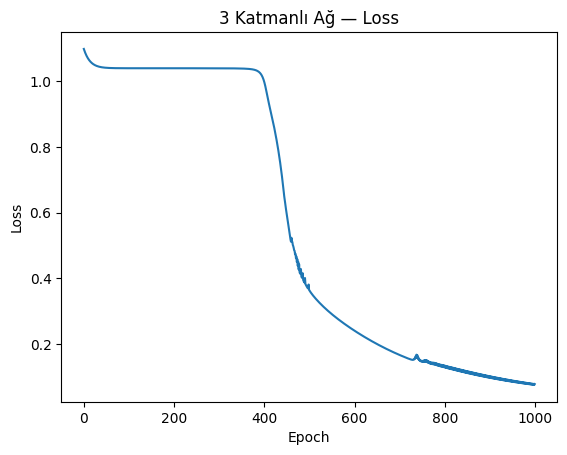

In [7]:
# ══════════════════════════════════════════════════════
# EĞİTİM DÖNGÜSÜ — HEPSİNİ BİR ARAYA GETİR
# ══════════════════════════════════════════════════════
#
# Q3'teki eğitim döngüsüyle aynı mantık
# Tek fark: modüler fonksiyonlar kullanıyoruz
# Ve 3 katman var, 2 değil
# ══════════════════════════════════════════════════════

np.random.seed(0)

# Ağırlıkları sıfırdan başlat
W1 = np.random.randn(D, H1) * 0.01
b1 = np.zeros(H1)
W2 = np.random.randn(H1, H2) * 0.01
b2 = np.zeros(H2)
W3 = np.random.randn(H2, C) * 0.01
b3 = np.zeros(C)

lr = 0.1
kayiplar = []

for epoch in range(1000):

    # FORWARD
    h1, cache1   = fc_forward(X, W1, b1)
    r1, rcache1  = relu_forward(h1)
    h2, cache2   = fc_forward(r1, W2, b2)
    r2, rcache2  = relu_forward(h2)
    skorlar, cache3 = fc_forward(r2, W3, b3)

    # LOSS
    e_s = np.exp(skorlar - np.max(skorlar, axis=1, keepdims=True))
    olasiliklar = e_s / np.sum(e_s, axis=1, keepdims=True)
    loss = -np.mean(np.log(olasiliklar[np.arange(N), y]))
    kayiplar.append(loss)

    # BACKWARD
    grad_skor = olasiliklar.copy()
    grad_skor[np.arange(N), y] -= 1
    grad_skor /= N

    grad_r2, grad_W3, grad_b3 = fc_backward(grad_skor, cache3)
    grad_h2 = relu_backward(grad_r2, rcache2)
    grad_r1, grad_W2, grad_b2 = fc_backward(grad_h2, cache2)
    grad_h1 = relu_backward(grad_r1, rcache1)
    grad_X,  grad_W1, grad_b1 = fc_backward(grad_h1, cache1)

    # GÜNCELLE
    W3 -= lr * grad_W3
    b3 -= lr * grad_b3
    W2 -= lr * grad_W2
    b2 -= lr * grad_b2
    W1 -= lr * grad_W1
    b1 -= lr * grad_b1

    if epoch % 200 == 0:
        tahminler = np.argmax(skorlar, axis=1)
        dogruluk = np.mean(tahminler == y)
        print(f"Epoch {epoch:4d}: loss={loss:.4f}, doğruluk=%{dogruluk*100:.0f}")

plt.plot(kayiplar)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("3 Katmanlı Ağ — Loss")
plt.show()

In [8]:
# ══════════════════════════════════════════════════════
# ASSIGNMENT 1 — GENEL ÖZET
# ══════════════════════════════════════════════════════

print("╔══════════════════════════════════════════════════╗")
print("║           CS231N — ASSIGNMENT 1 ÖZET             ║")
print("╠══════════════════════════════════════════════════╣")
print("║                                                  ║")
print("║  Q1 — kNN:                                       ║")
print("║    Parametre yok, veriyi ezberler                ║")
print("║    Tahmin: mesafe hesapla, komşuya sor           ║")
print("║    Doğruluk: ~%27                                ║")
print("║                                                  ║")
print("║  Q2 — Softmax:                                   ║")
print("║    W öğrenir (D×C parametre)                     ║")
print("║    Tahmin: W@x → olasılık                        ║")
print("║    Doğruluk: ~%35                                ║")
print("║                                                  ║")
print("║  Q3 — İki Katmanlı Ağ:                           ║")
print("║    W1, W2 öğrenir, ReLU ile eğri sınırlar        ║")
print("║    Softmax'tan daha güçlü                        ║")
print("║    Doğruluk: ~%50                                ║")
print("║                                                  ║")
print("║  Q4 — Image Features:                            ║")
print("║    Ham piksel yerine HOG + Color Histogram       ║")
print("║    Işık ve konumdan bağımsız özellikler          ║")
print("║    Doğruluk: ~%38 (kNN ile bile!)                ║")
print("║                                                  ║")
print("║  Q5 — Fully Connected Net:                       ║")
print("║    İstediğin kadar katman ekle                   ║")
print("║    Modüler yapı: fc_forward, relu_forward...     ║")
print("║    Daha derin → daha güçlü!                      ║")
print("║                                                  ║")
print("╚══════════════════════════════════════════════════╝")

╔══════════════════════════════════════════════════╗
║           CS231N — ASSIGNMENT 1 ÖZET             ║
╠══════════════════════════════════════════════════╣
║                                                  ║
║  Q1 — kNN:                                       ║
║    Parametre yok, veriyi ezberler                ║
║    Tahmin: mesafe hesapla, komşuya sor           ║
║    Doğruluk: ~%27                                ║
║                                                  ║
║  Q2 — Softmax:                                   ║
║    W öğrenir (D×C parametre)                     ║
║    Tahmin: W@x → olasılık                        ║
║    Doğruluk: ~%35                                ║
║                                                  ║
║  Q3 — İki Katmanlı Ağ:                           ║
║    W1, W2 öğrenir, ReLU ile eğri sınırlar        ║
║    Softmax'tan daha güçlü                        ║
║    Doğruluk: ~%50                                ║
║                                             